# 5. Redes neuronales y retropropagación

**Objetivo.** Construir una red como composición de capas y observar cómo la regla de la cadena distribuye el gradiente por todos sus parámetros.

Una capa oculta calcula $H=\phi(XW_1+b_1)$ y la salida $\hat y=HW_2+b_2$. Sin una activación no lineal $\phi$, dos capas lineales equivalen a una sola.

In [1]:
import random
import torch
import matplotlib.pyplot as plt

SEMILLA = 42
random.seed(SEMILLA)
torch.manual_seed(SEMILLA)
torch.set_printoptions(precision=3, sci_mode=False)
print(f"PyTorch {torch.__version__} · semilla {SEMILLA}")

PyTorch 2.14.0 · semilla 42


## Activaciones

ReLU aplica $\max(0,x)$. Introduce no linealidad y mantiene gradientes positivos en su región activa. Sigmoid comprime valores a $(0,1)$.

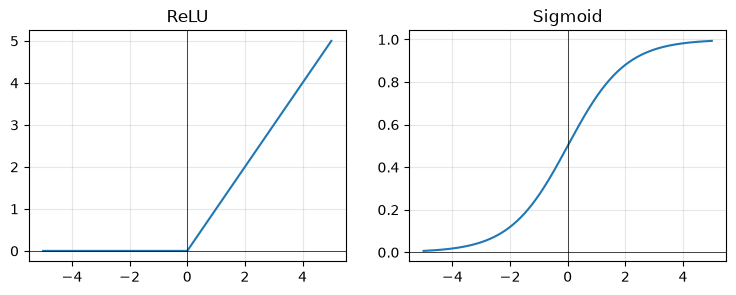

In [2]:
z = torch.linspace(-5, 5, 300)
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(z, torch.relu(z)); ax[0].set_title("ReLU")
ax[1].plot(z, torch.sigmoid(z)); ax[1].set_title("Sigmoid")
for a in ax:
    a.grid(alpha=.3); a.axhline(0, color="black", lw=.5); a.axvline(0, color="black", lw=.5)
fig.savefig("imagenes/funciones_activacion.png", dpi=160, bbox_inches="tight")
plt.show()

## Propagación hacia delante y hacia atrás

Conservamos el gradiente de la representación oculta para inspeccionarlo. Normalmente PyTorch lo utiliza internamente.

In [3]:
X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
y = torch.tensor([[0.], [1.], [1.], [0.]])
W1 = torch.randn(2, 4, requires_grad=True)
b1 = torch.zeros(4, requires_grad=True)
W2 = torch.randn(4, 1, requires_grad=True)
b2 = torch.zeros(1, requires_grad=True)

H = torch.relu(X @ W1 + b1)
H.retain_grad()
logits = H @ W2 + b2
perdida = torch.nn.functional.binary_cross_entropy_with_logits(logits, y)
perdida.backward()

print("formas: X", X.shape, "H", H.shape, "salida", logits.shape)
print("pérdida:", perdida.item())
for nombre, p in {"W1": W1, "b1": b1, "H": H, "W2": W2, "b2": b2}.items():
    print(f"{nombre}: norma del gradiente = {p.grad.norm().item():.4f}")

formas: X torch.Size([4, 2]) H torch.Size([4, 4]) salida torch.Size([4, 1])
pérdida: 0.7451106309890747
W1: norma del gradiente = 0.1296
b1: norma del gradiente = 0.0943
H: norma del gradiente = 0.2859
W2: norma del gradiente = 0.3313
b2: norma del gradiente = 0.1687


## Verificación numérica

Las diferencias finitas permiten comprobar un gradiente concreto. La aproximación no será idéntica, pero debe ser muy cercana.

In [4]:
def perdida_con_w(valor):
    W = W1.detach().clone()
    W[0, 0] = valor
    h = torch.relu(X @ W + b1.detach())
    salida = h @ W2.detach() + b2.detach()
    return torch.nn.functional.binary_cross_entropy_with_logits(salida, y)

eps = 1e-3
valor = W1.detach()[0, 0]
numerico = (perdida_con_w(valor + eps) - perdida_con_w(valor - eps)) / (2 * eps)
print("automático:", W1.grad[0, 0].item())
print("numérico:", numerico.item())

automático: -0.043527234345674515
numérico: -0.04357099160552025


## Preguntas

1. Elimina ReLU y demuestra que las capas se reducen a una transformación lineal.
2. ¿Qué significa que la norma del gradiente de una capa sea casi cero?
3. ¿Por qué usamos una pérdida que recibe *logits*?

**Idea clave:** la red predice hacia delante; la retropropagación reutiliza el grafo para calcular las derivadas hacia atrás.